/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

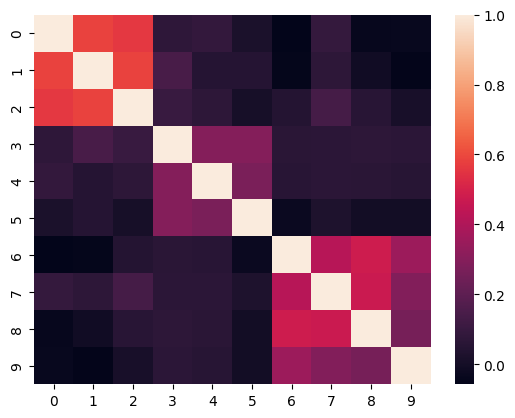

Top 2 similar sentences:
The bowler took a wicket in the final over 0.83883524
India won the cricket match by 5 runs 0.58555377


In [1]:
!pip install -q sentence-transformers seaborn scikit-learn

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

model = SentenceTransformer('all-MiniLM-L6-v2')

sentences = [
    "The batsman scored a century in the match",
    "The bowler took a wicket in the final over",
    "India won the cricket match by 5 runs",
    "Add salt and spices while cooking the curry",
    "Boil the vegetables before frying them",
    "The recipe requires fresh ingredients",
    "Use strong passwords to protect your data",
    "Cyber attacks can compromise sensitive information",
    "Encryption helps secure communication",
    "Firewalls prevent unauthorized access"
]

embeddings = model.encode(sentences)

similarity_matrix = cosine_similarity(embeddings)

sns.heatmap(similarity_matrix)
plt.show()

query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

scores = cosine_similarity(query_embedding, embeddings)[0]
top_indices = scores.argsort()[-2:][::-1]

print("Top 2 similar sentences:")
for i in top_indices:
    print(sentences[i], scores[i])